In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [13]:

df = pd.read_csv("customer_booking.csv",
                  encoding='latin-1')

print(df.shape)          # rows and columns
print(df.head())         # first 5 rows
print(df.describe())     # statistics
print(df.isnull().sum()) # missing values

(50000, 14)
   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1   
1            3        Sat  AKLDEL    New Zealand                    0   
2           17        Wed  AKLDEL          India                    1   
3            4        Sat  AKLDEL    New Zealand                    0   
4           15        Wed  AKLDEL          India                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                  

In [14]:

le = LabelEncoder()

text_columns = ['sales_channel',
                'trip_type',
                'flight_day',
                'route',
                'booking_origin']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   num_passengers  sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2              0          2            262              19   
1               1              0          2            112              20   
2               2              0          2            243              22   
3               1              0          2             96              31   
4               2              0          2             68              22   

   flight_hour  flight_day  route  booking_origin  wants_extra_baggage  \
0            7           2      0              61                    1   
1            3           2      0              61                    0   
2           17           6      0              36                    1   
3            4           2      0              61                    0   
4           15           6      0              36                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                  

In [15]:
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 13)
y shape: (50000,)


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (40000, 13)
Testing size: (10000, 13)


In [17]:

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
predictions = model.predict(X_test)

# Accuracy score
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2%}")

# Detailed classification report
print(classification_report(y_test, predictions))

cv_scores = cross_val_score(
    model, X, y,
    cv=5,
    scoring='roc_auc'
)
print(f"CV ROC AUC: {cv_scores.mean():.2%}")
print(f"CV Std Dev: {cv_scores.std():.2%}")

Accuracy: 70.87%
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      8520
           1       0.30      0.71      0.42      1480

    accuracy                           0.71     10000
   macro avg       0.62      0.71      0.61     10000
weighted avg       0.84      0.71      0.75     10000

CV ROC AUC: 38.86%
CV Std Dev: 24.19%


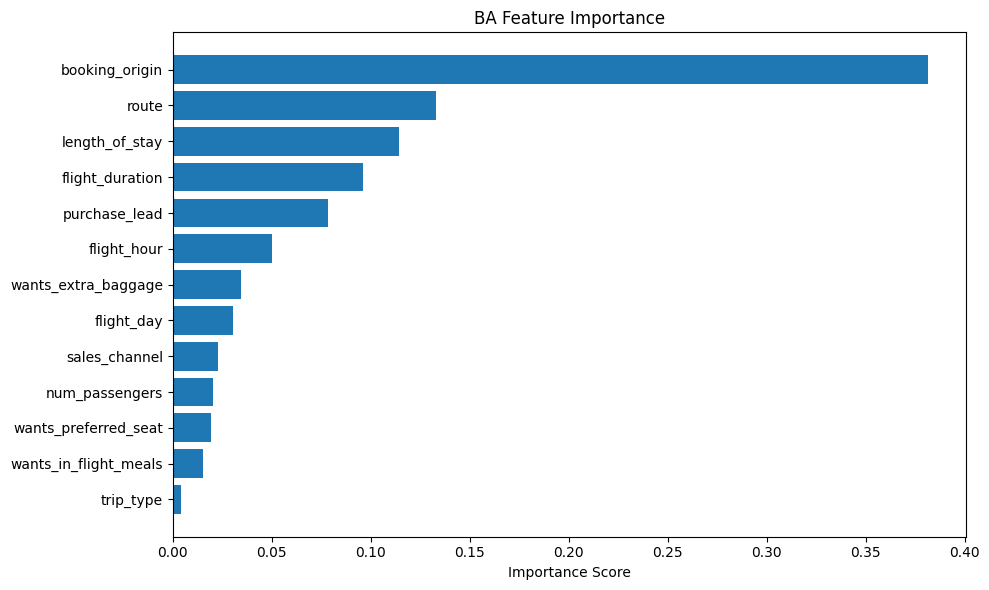

In [19]:


# Get feature importance scores
importance = model.feature_importances_

# Get feature names
feature_names = X.columns.tolist()

# Sort by importance
indices = np.argsort(importance)

# Plot the chart
plt.figure(figsize=(10, 6))
plt.title('BA Feature Importance')
plt.barh(
    range(len(indices)),
    importance[indices]
)
plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [20]:
print(y.value_counts(normalize=True))

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64


In [21]:
print("Class distribution:")
print(df['booking_complete'].value_counts())
print("\nPercentage:")
print(df['booking_complete'].value_counts(normalize=True) * 100)

Class distribution:
booking_complete
0    42522
1     7478
Name: count, dtype: int64

Percentage:
booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64


In [22]:
# SMOTE import karo
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Train test split — pehle split karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# SMOTE lagao — sirf training data pe
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# Result dekho
print("SMOTE se pehle:")
print(pd.Series(y_train).value_counts())

print("\nSMOTE ke baad:")
print(pd.Series(y_train_sm).value_counts())

SMOTE se pehle:
booking_complete
0    34002
1     5998
Name: count, dtype: int64

SMOTE ke baad:
booking_complete
0    34002
1    34002
Name: count, dtype: int64


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Naya model — SMOTE wale data pe train karo
model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_smote.fit(X_train_sm, y_train_sm)

# Predict karo
y_pred_smote = model_smote.predict(X_test)
y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

# Results dekho
print("=== SMOTE ke baad results ===")
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=['Not Booked', 'Booked']
))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_smote):.4f}")

=== SMOTE ke baad results ===
              precision    recall  f1-score   support

  Not Booked       0.89      0.88      0.89      8520
      Booked       0.36      0.39      0.37      1480

    accuracy                           0.81     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.81      0.81      0.81     10000

ROC AUC: 0.7528


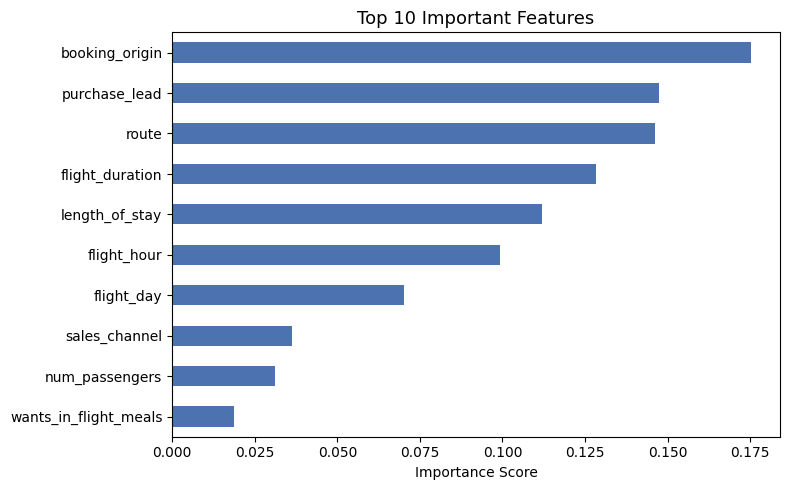

Sabse important feature: booking_origin


In [32]:
import matplotlib.pyplot as plt

importances = pd.Series(model_smote.feature_importances_,
    index=X_train.columns).sort_values(ascending=False).head(10)

# Chart banao
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 Important Features', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150)
plt.show()

print("Sabse important feature:", importances.index[0])

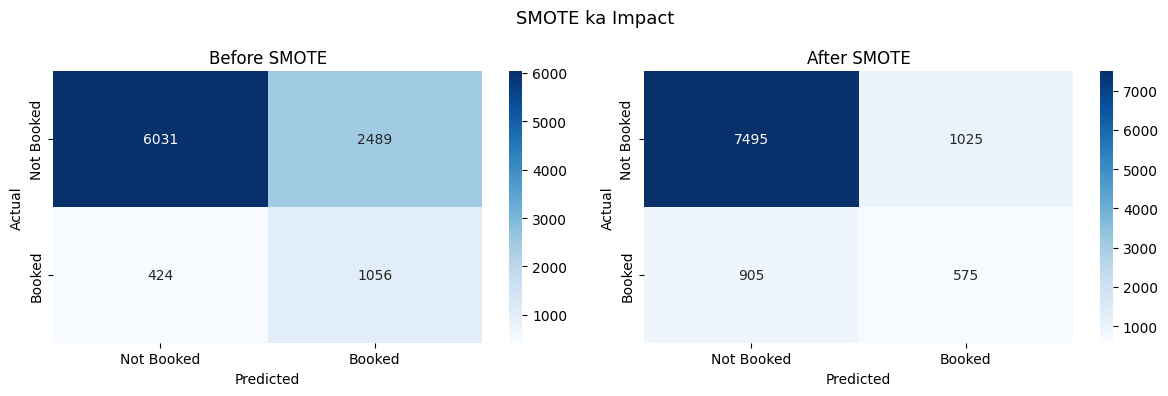

In [35]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Dono models ke confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [predictions, y_pred_smote],
    ['Before SMOTE', 'After SMOTE']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues',
        xticklabels=['Not Booked', 'Booked'],
        yticklabels=['Not Booked', 'Booked'],
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('SMOTE ka Impact', fontsize=13)
plt.tight_layout()
plt.savefig('images/smote_comparison.png', dpi=150)
plt.show()

In [29]:
import os

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')